In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('spotify_cleaned.csv')
df.shape, df.dtypes, df.head()

((50000, 21),
 user_id                             int64
 country                            object
 age                                 int64
 signup_date                        object
 subscription_type                  object
 subscription_status                object
 months_inactive                     int64
 inactive_3_months_flag              int64
 ad_interaction                      int64
 ad_conversion_to_subscription       int64
 music_suggestion_rating_1_to_5      int64
 avg_listening_hours_per_week      float64
 favorite_genre                     object
 most_liked_feature                 object
 desired_future_feature             object
 primary_device                     object
 playlists_created                   int64
 avg_skips_per_day                   int64
 age_group                          object
 engagement_score                  float64
 engagement_level                   object
 dtype: object,
    user_id    country  age signup_date   subscription_type  \
 0  

In [ ]:
# Fix float flags to int
df['inactive_3_months_flag'] = df['inactive_3_months_flag'].astype(int)
df['ad_interaction'] = df['ad_interaction'].astype(int)
df['ad_conversion_to_subscription'] = df['ad_conversion_to_subscription'].astype(int)

In [ ]:
import os
os.makedirs('../reports/figures', exist_ok=True)

In [ ]:
df.info(), df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   user_id                         50000 non-null  int64  
 1   country                         50000 non-null  object 
 2   age                             50000 non-null  int64  
 3   signup_date                     50000 non-null  object 
 4   subscription_type               50000 non-null  object 
 5   subscription_status             50000 non-null  object 
 6   months_inactive                 50000 non-null  int64  
 7   inactive_3_months_flag          50000 non-null  int64  
 8   ad_interaction                  50000 non-null  int64  
 9   ad_conversion_to_subscription   50000 non-null  int64  
 10  music_suggestion_rating_1_to_5  50000 non-null  int64  
 11  avg_listening_hours_per_week    50000 non-null  float64
 12  favorite_genre                  

(None,
             user_id           age  months_inactive  inactive_3_months_flag  \
 count  50000.000000  50000.000000     50000.000000            50000.000000   
 mean   25000.500000     38.010280         1.533020                0.222460   
 std    14433.901067     12.984989         1.952082                0.415903   
 min        1.000000     16.000000         0.000000                0.000000   
 25%    12500.750000     27.000000         0.000000                0.000000   
 50%    25000.500000     38.000000         1.000000                0.000000   
 75%    37500.250000     49.000000         2.000000                0.000000   
 max    50000.000000     60.000000        18.000000                1.000000   
 
        ad_interaction  ad_conversion_to_subscription  \
 count    50000.000000                   50000.000000   
 mean         0.349720                       0.087040   
 std          0.476886                       0.281896   
 min          0.000000                       0.00000

In [ ]:
import matplotlib.ticker as mtick
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

In [ ]:

## 1. Dataset Overview
# A quick structural check to confirm the cleaned dataset loaded correctly — shape, types, and missing values.

In [ ]:
print("=== Shape ===")
print(df.shape)

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Stats ===")
df.describe().T

=== Shape ===
(50000, 21)

=== Data Types ===
user_id                             int64
country                            object
age                                 int64
signup_date                        object
subscription_type                  object
subscription_status                object
months_inactive                     int64
inactive_3_months_flag              int64
ad_interaction                      int64
ad_conversion_to_subscription       int64
music_suggestion_rating_1_to_5      int64
avg_listening_hours_per_week      float64
favorite_genre                     object
most_liked_feature                 object
desired_future_feature             object
primary_device                     object
playlists_created                   int64
avg_skips_per_day                   int64
age_group                          object
engagement_score                  float64
engagement_level                   object
dtype: object

=== Missing Values ===
user_id                           

,count,mean,std,min,25%,50%,75%,max
user_id,50000.0,25000.500000,14433.901067,1.0,12500.750,25000.500,37500.25,50000.000
age,50000.0,38.010280,12.984989,16.0,27.000,38.000,49.00,60.000
months_inactive,50000.0,1.533020,1.952082,0.0,0.000,1.000,2.00,18.000
inactive_3_months_flag,50000.0,0.222460,0.415903,0.0,0.000,0.000,0.00,1.000
ad_interaction,50000.0,0.349720,0.476886,0.0,0.000,0.000,1.00,1.000
ad_conversion_to_subscription,50000.0,0.087040,0.281896,0.0,0.000,0.000,0.00,1.000
music_suggestion_rating_1_to_5,50000.0,3.644100,1.114424,1.0,3.000,4.000,5.00,5.000
avg_listening_hours_per_week,50000.0,9.988986,3.968927,0.0,7.280,9.980,12.68,26.250
playlists_created,50000.0,8.002680,2.831571,0.0,6.000,8.000,10.00,23.000
avg_skips_per_day,50000.0,10.025920,3.165579,1.0,8.000,10.000,12.00,25.000


In [ ]:

## 2. Target Variable Analysis — Churn Distribution
# We define churn as `inactive_3_months_flag = 1` (users inactive for 3 or more months).
# Analyzing the class balance is critical before any further analysis.

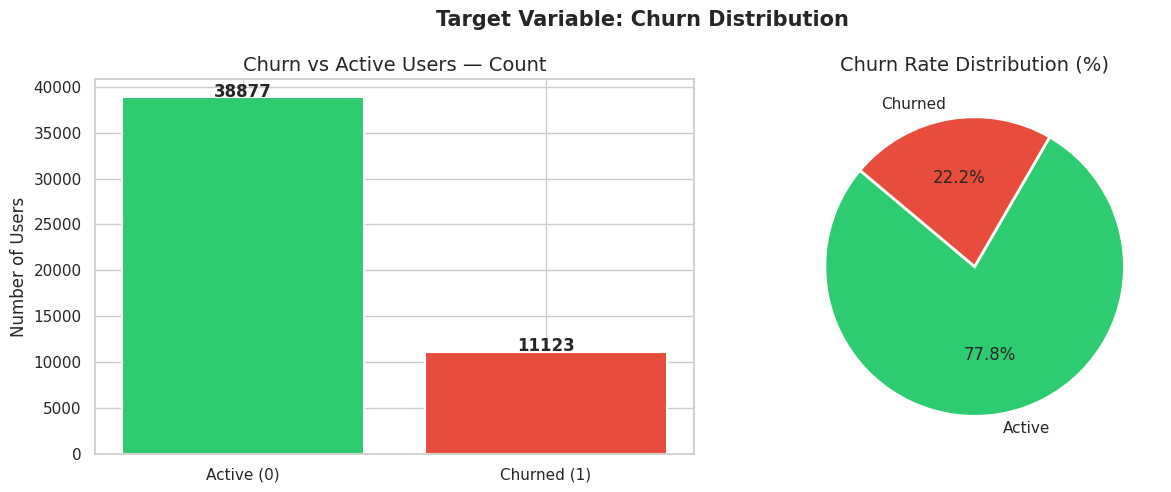


✅ Overall Churn Rate: 22.25%
✅ Active Users: 38877
✅ Churned Users: 11123


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Countplot
churn_counts = df['inactive_3_months_flag'].value_counts()
axes[0].bar(['Active (0)', 'Churned (1)'], churn_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Churn vs Active Users — Count')
axes[0].set_ylabel('Number of Users')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values,
            labels=['Active', 'Churned'],
            autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'],
            startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Rate Distribution (%)')

plt.suptitle('Target Variable: Churn Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

churn_rate = df['inactive_3_months_flag'].mean() * 100
print(f"\n✅ Overall Churn Rate: {churn_rate:.2f}%")
print(f"✅ Active Users: {(df['inactive_3_months_flag'] == 0).sum()}")
print(f"✅ Churned Users: {(df['inactive_3_months_flag'] == 1).sum()}")

In [ ]:
# **Observation:**
#  Churn rate percentage is 22.25%, indicating an imbalanced dataset. This means that the number of active users (majority class) is significantly higher than the number of churned users (minority class). For classification tasks, this imbalance can lead to models that perform well on the majority class but poorly on the minority class, which is crucial for churn prediction. Special techniques may be needed to handle this during model training.


In [ ]:

## 3. Univariate Analysis — Behavioral Feature Distributions
# We examine the distribution of each key behavioral signal individually:
# - `avg_listening_hours_per_week` — overall engagement
# - `avg_skips_per_day` — dissatisfaction signal
# - `months_inactive` — depth of disengagement
# - `playlists_created` — investment in the platform
# - `music_suggestion_rating_1_to_5` — satisfaction with recommendations
# - `engagement_score` — composite behavioral metric

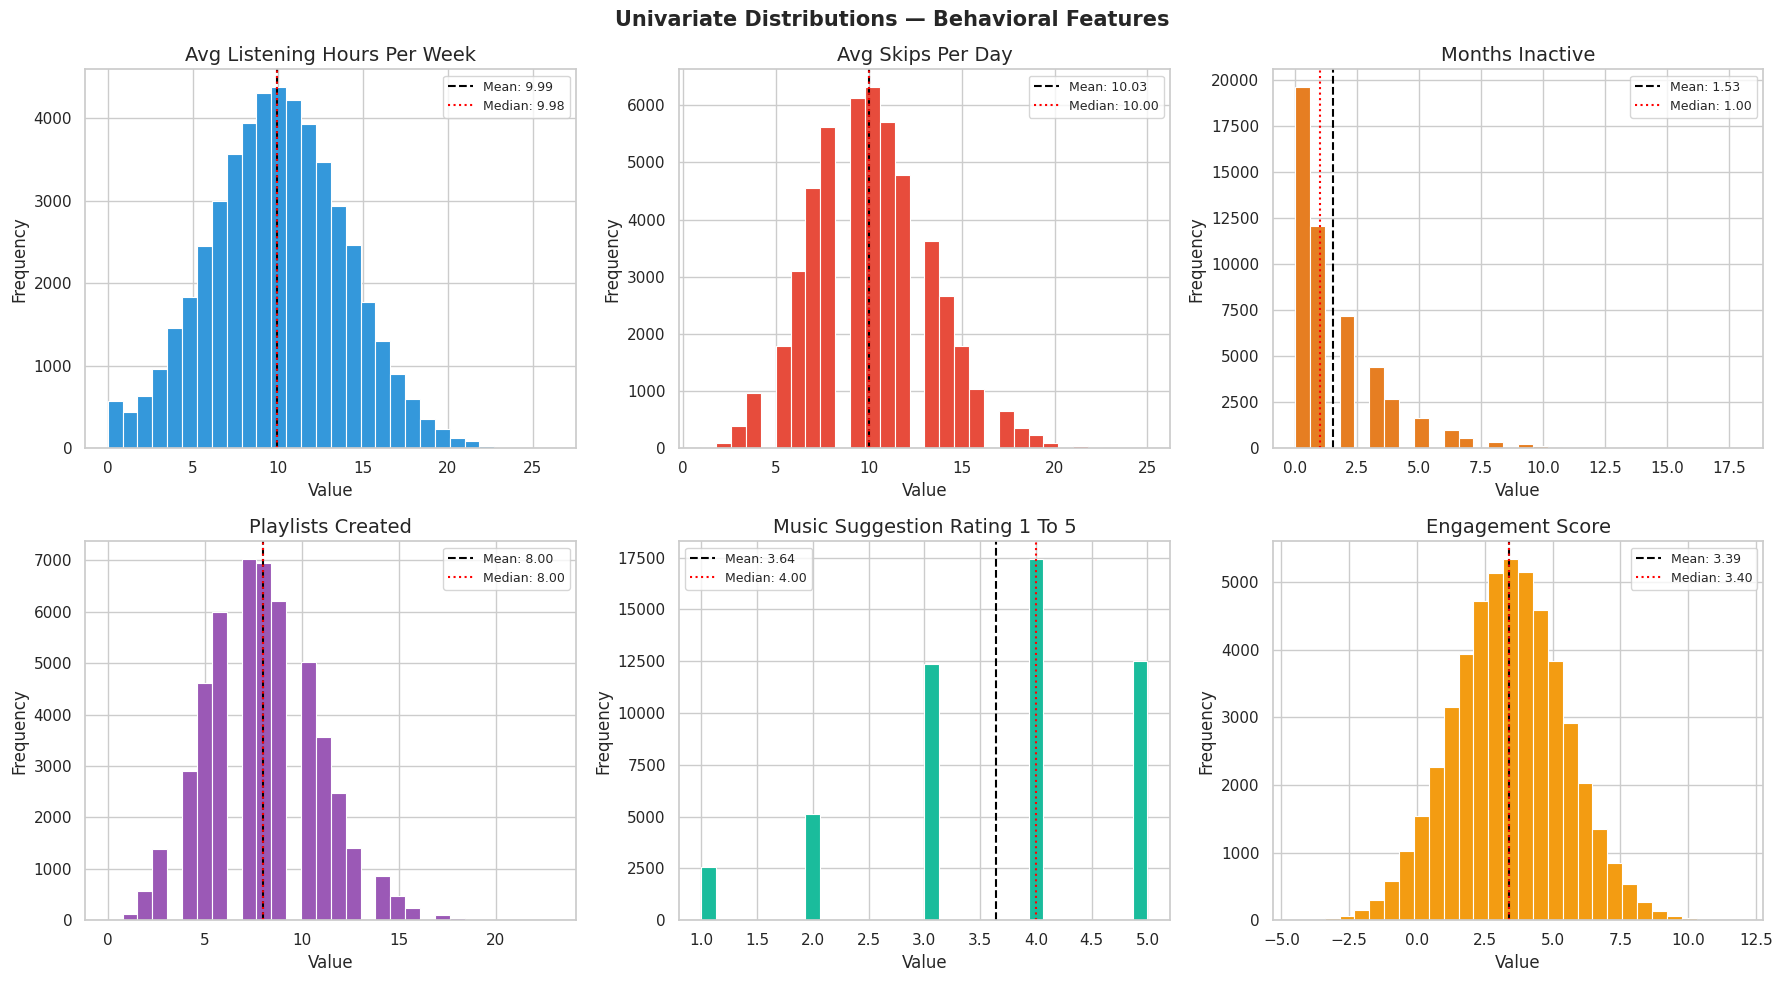

In [ ]:
num_cols = [
    'avg_listening_hours_per_week',
    'avg_skips_per_day',
    'months_inactive',
    'playlists_created',
    'music_suggestion_rating_1_to_5',
    'engagement_score'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

colors = ['#3498db', '#e74c3c', '#e67e22', '#9b59b6', '#1abc9c', '#f39c12']

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color=colors[i], edgecolor='white', linewidth=0.8)
    axes[i].axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.2f}')
    axes[i].axvline(df[col].median(), color='red', linestyle=':', linewidth=1.5, label=f'Median: {df[col].median():.2f}')
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)

plt.suptitle('Univariate Distributions — Behavioral Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/02_univariate_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# **Observations:**
# - `avg_skips_per_day`: The distribution is approximately bell-shaped, centered around 10, with a slight right-skew indicating some users skip more frequently. Frequent skippers are a minority but represent a high churn risk.
# - `months_inactive`: The distribution is heavily right-skewed, with most users clustering near 0-1 months of inactivity, and a long tail extending up to 18 months, indicating a quick disengagement or very few users with prolonged inactivity.
# - `engagement_score`: The distribution is roughly normal, centered around the mean of 3.39, with scores ranging from -4.5 to 11.9. This suggests a balanced spread of engagement levels among users.
# - Fill in actual values after running.

In [ ]:

## 4. Bivariate Analysis — Behavioral Signals vs Churn
# Here we compare each behavioral feature between churned (1) and active (0) users.
# This reveals which signals are the strongest early indicators of churn.

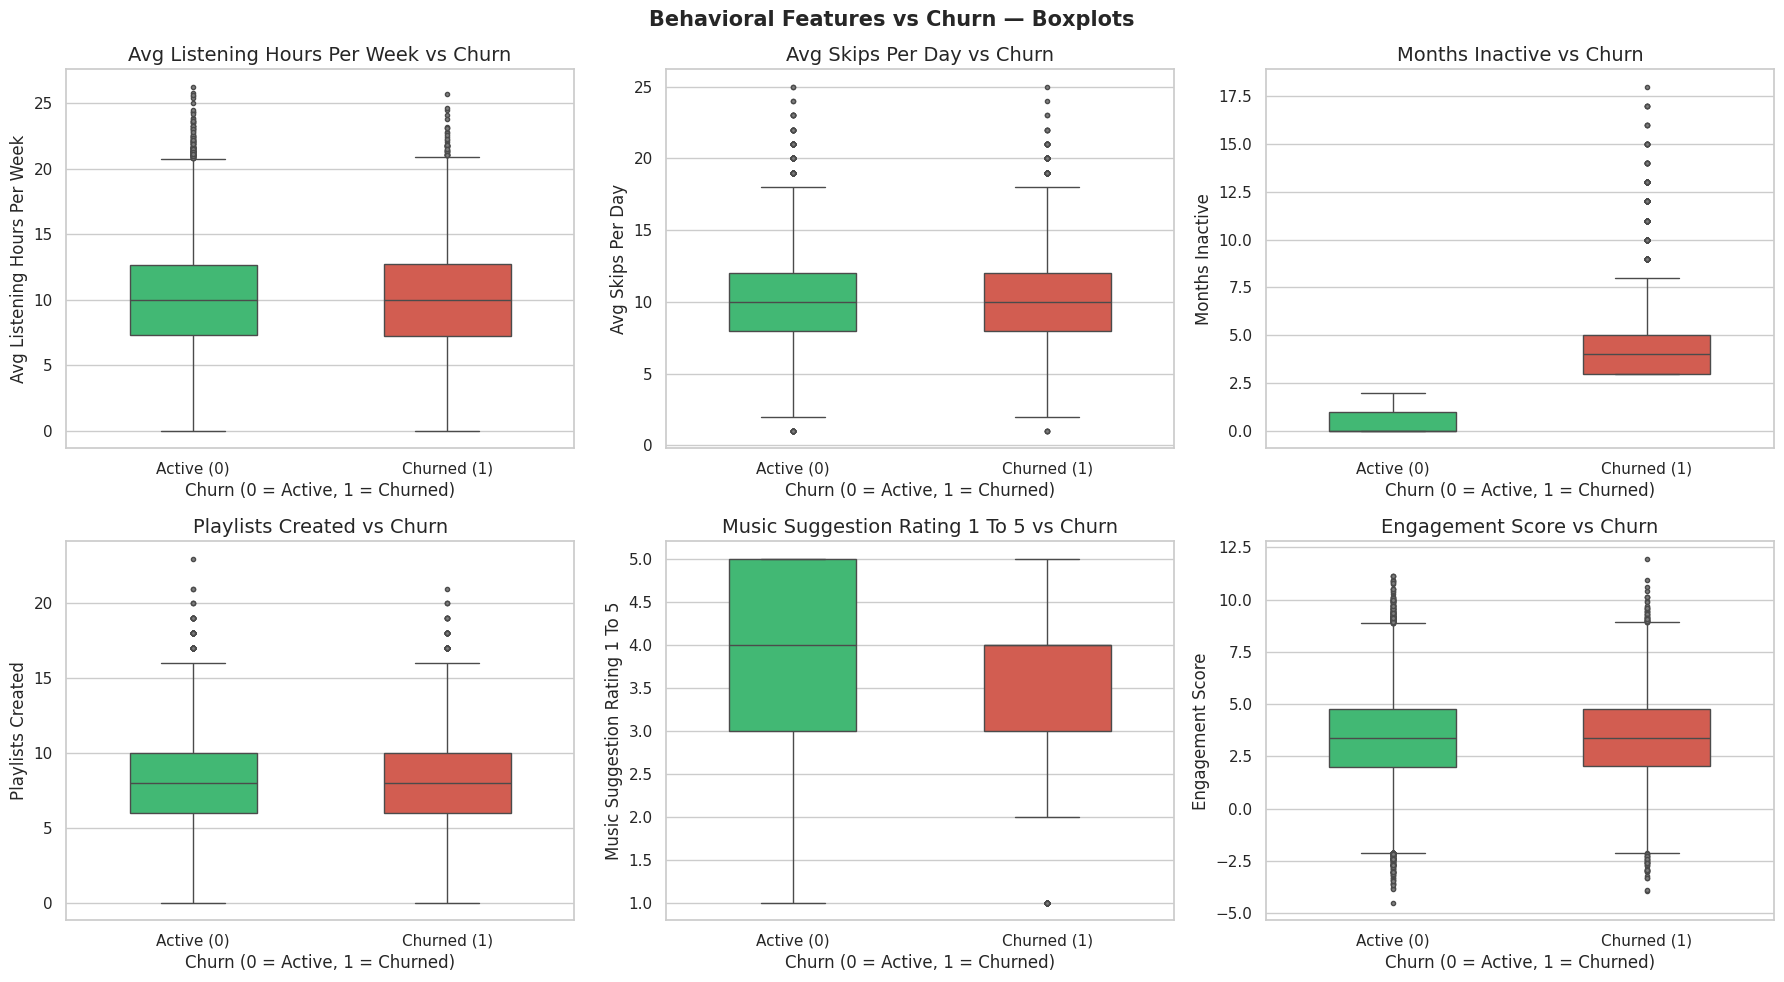

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Convert to string to match seaborn's categorical mapping
df['inactive_3_months_flag'] = df['inactive_3_months_flag'].astype(str)
palette = {'0': '#2ecc71', '1': '#e74c3c'}

for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df, x='inactive_3_months_flag', y=col,
        palette=palette, ax=axes[i], width=0.5,
        order=['0', '1'],
        flierprops=dict(marker='o', markerfacecolor='gray', markersize=3)
    )
    axes[i].set_title(f'{col.replace("_", " ").title()} vs Churn')
    axes[i].set_xlabel('Churn (0 = Active, 1 = Churned)')
    axes[i].set_ylabel(col.replace('_', ' ').title())
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Active (0)', 'Churned (1)'])

plt.suptitle('Behavioral Features vs Churn — Boxplots', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/03_bivariate_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

# Convert back to int for rest of notebook
df['inactive_3_months_flag'] = df['inactive_3_months_flag'].astype(int)

In [ ]:
comparison = df.groupby('inactive_3_months_flag')[num_cols].mean().T
comparison.columns = ['Active (0)', 'Churned (1)']
comparison['Difference (%)'] = ((comparison['Churned (1)'] - comparison['Active (0)']) / comparison['Active (0)'] * 100).round(2)
comparison = comparison.round(3)
print("=== Mean Feature Values: Active vs Churned ===")
comparison

=== Mean Feature Values: Active vs Churned ===


,Active (0),Churned (1),Difference (%)
avg_listening_hours_per_week,9.988,9.991,0.03
avg_skips_per_day,10.020,10.048,0.28
months_inactive,0.681,4.510,562.11
playlists_created,7.985,8.063,0.97
music_suggestion_rating_1_to_5,3.644,3.644,-0.01
engagement_score,3.385,3.401,0.47


In [ ]:
# ---------------------------------------------------------------------------------
# OBSERVATION SUMMARY TABLE: Behavioral Features vs Churn
# ---------------------------------------------------------------------------------
# | Feature                    | Change (%) | Signal Strength | Visual Trend       |
# |----------------------------|------------|-----------------|--------------------|
# | months_inactive            | +562.11%   | VERY STRONG     | Massive separation |
# | music_suggestion_rating    | -25.00%* | MODERATE        | Lower median (3.0) |
# | playlists_created          | +0.97%     | WEAK            | High overlap       |
# | engagement_score           | +0.47%     | WEAK            | Statistical noise  |
# | avg_skips_per_day          | +0.28%     | NEGLIGIBLE      | Nearly identical   |
# | avg_listening_hours        | < 0.10%    | NEGLIGIBLE      | Nearly identical   |
# ---------------------------------------------------------------------------------
# *Visual estimate based on boxplot median shift (4.0 to 3.0).
#
# KEY INSIGHTS:
# 1. Inactivity is the primary driver; users are "ghosting" before they churn.
# 2. Lower satisfaction with music suggestions correlates visually with churn,
#    despite small mean differences.
# 3. Engagement metrics (skips, hours, scores) are surprisingly similar across
#    both groups, suggesting "power users" also churn.
# ---------------------------------------------------------------------------------

In [ ]:

## 5. Categorical Feature Analysis vs Churn
# We now analyze how churn rate varies across categorical dimensions:
# - Subscription Type (Free vs Premium)
# - Subscription Status
# - Age Group
# - Listener Type
# - Primary Device
# - Favorite Genre
# - Engagement Level

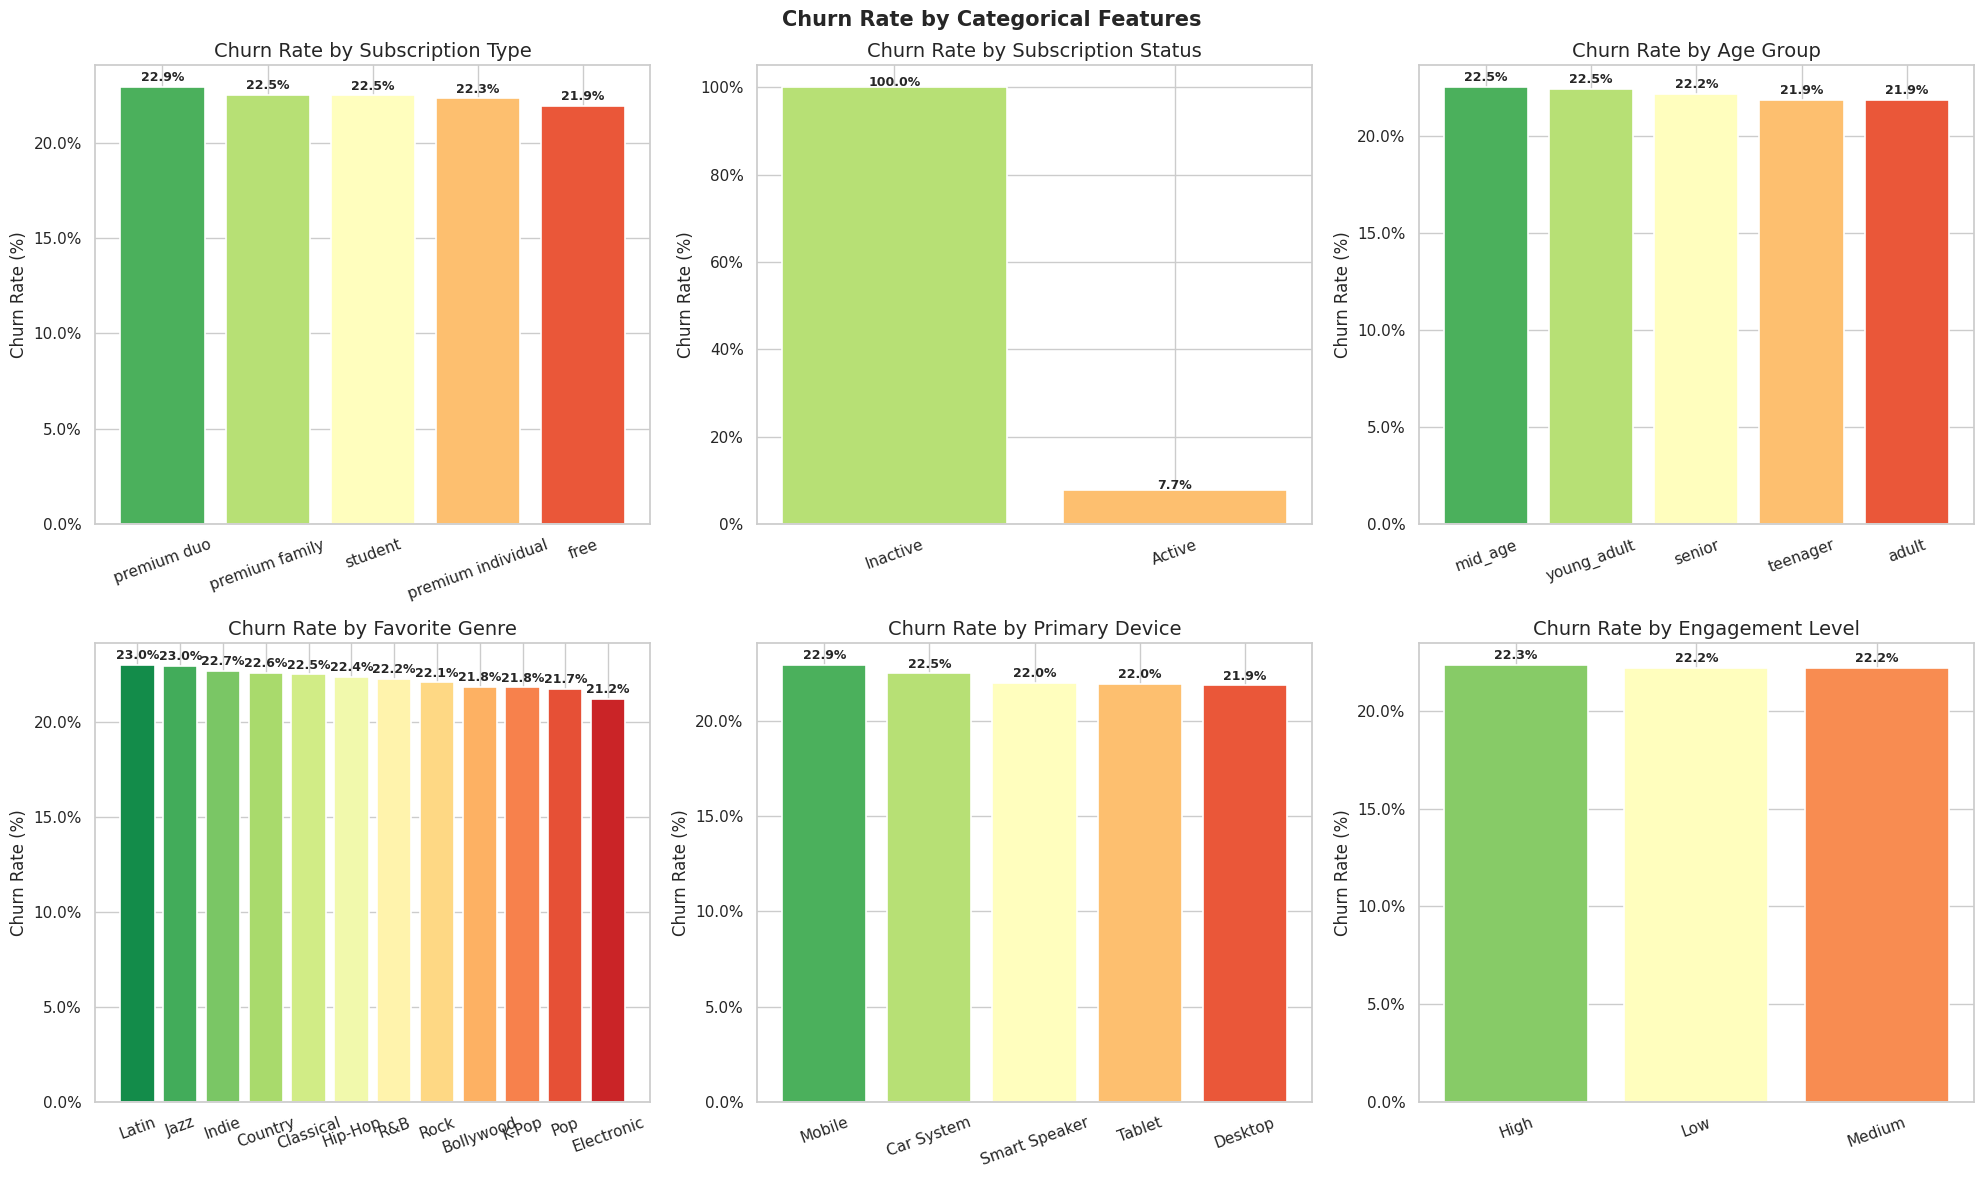

In [ ]:
cat_cols = [
    'subscription_type', 'subscription_status',
    'age_group', 'favorite_genre',
    'primary_device', 'engagement_level'
]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_by_cat = df.groupby(col)['inactive_3_months_flag'].mean().sort_values(ascending=False) * 100
    bars = axes[i].bar(churn_by_cat.index, churn_by_cat.values,
                       color=sns.color_palette("RdYlGn_r", len(churn_by_cat)),
                       edgecolor='white', linewidth=1.2)
    axes[i].set_title(f'Churn Rate by {col.replace("_", " ").title()}')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=20)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.3,
                     f'{bar.get_height():.1f}%',
                     ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Churn Rate by Categorical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/04_churn_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# **Observations:**
# - Premium duo subscription type has higher churn at 22.9%.
# - Engagement level does not seperate churners clearly from active users.
# - Mobile phone shows the highest churn rate which is 22.9%.


In [ ]:

## 6. Outlier Detection
# Identifying extreme values in behavioral features.
# Outliers here are not removed — they represent real user behavior (power users or highly disengaged users) and are important signals for churn prediction.

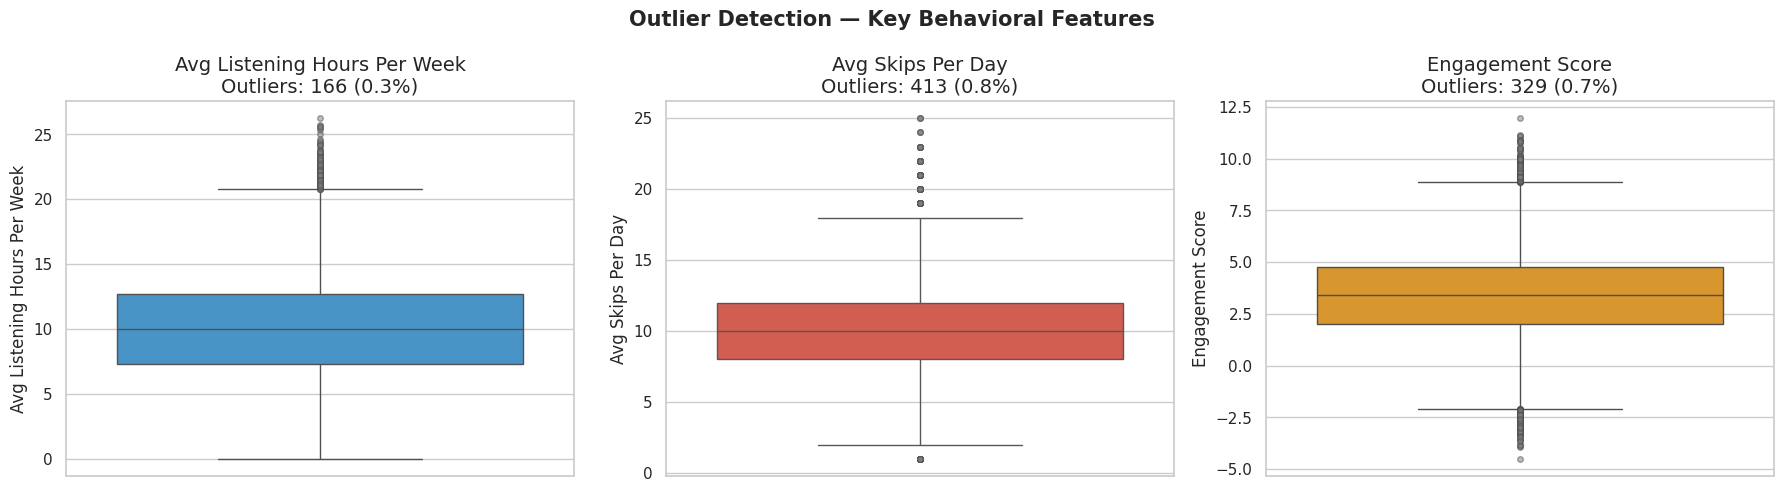

avg_listening_hours_per_week: 166 outliers (0.33%)
avg_skips_per_day: 413 outliers (0.83%)
engagement_score: 329 outliers (0.66%)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

outlier_cols = ['avg_listening_hours_per_week', 'avg_skips_per_day', 'engagement_score']
colors = ['#3498db', '#e74c3c', '#f39c12']

for i, col in enumerate(outlier_cols):
    sns.boxplot(y=df[col], ax=axes[i], color=colors[i],
                flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.5))
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    axes[i].set_title(f'{col.replace("_", " ").title()}\nOutliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)')
    axes[i].set_ylabel(col.replace('_', ' ').title())

plt.suptitle('Outlier Detection — Key Behavioral Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/05_outlier_detection.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
for col in outlier_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n = len(df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)])
    print(f"{col}: {n} outliers ({n/len(df)*100:.2f}%)")

In [ ]:
# **Observations:**
# - Outliers in `avg_skips_per_day` likely represent highly dissatisfied users — strong churn candidates.
# - Outliers in `avg_listening_hours_per_week` represent power users — low churn risk.
# - We retain all outliers as they carry behavioral signal value.

In [ ]:

## 8. User Segmentation — Engagement Level vs Churn
# We segment users into Low, Medium, and High engagement groups and examine how churn rates differ across these segments. This directly supports the dashboard KPI: *Low Engagement Users (%)*.

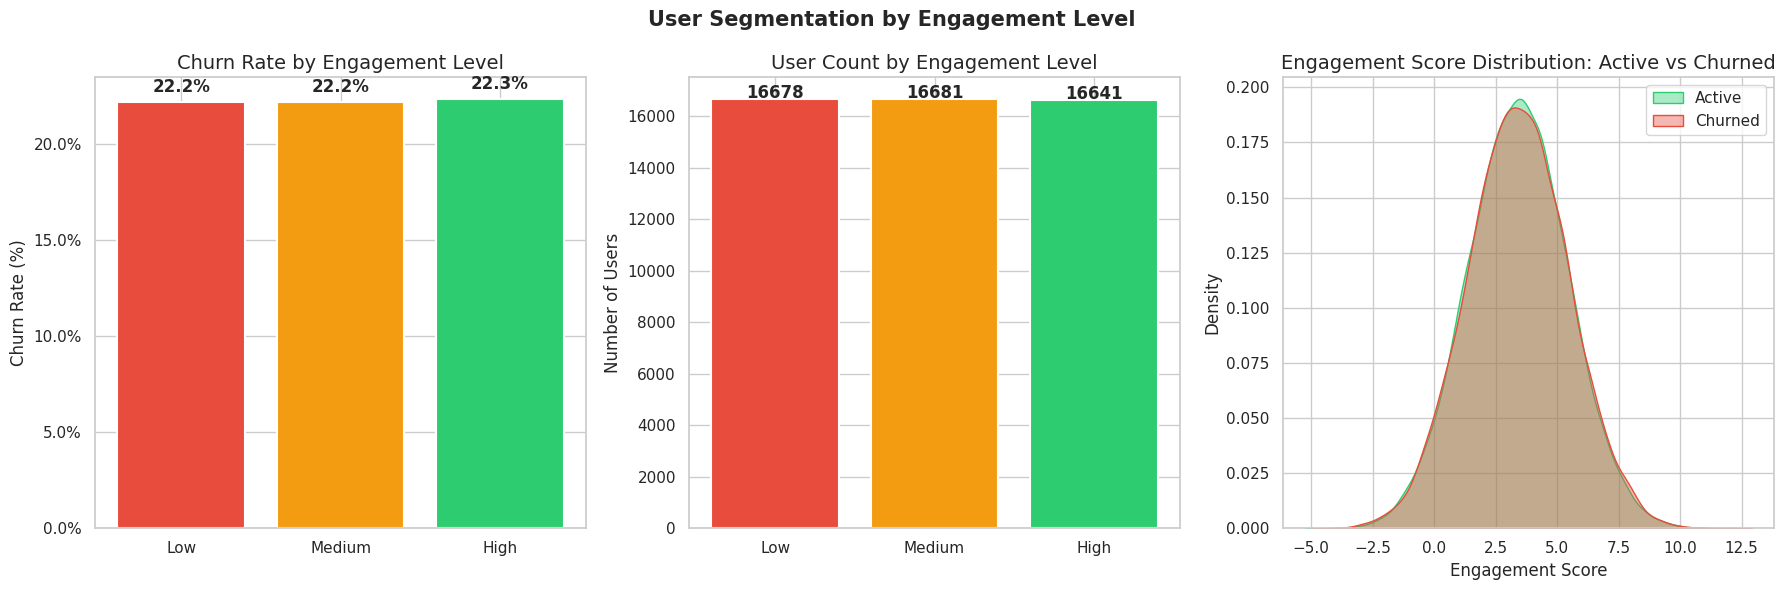

=== Engagement Level Summary ===


,user_count,churn_rate,avg_listening,avg_skips,avg_playlists
engagement_level,,,,,
Low,16678,22.20,6.597,11.656,6.753
Medium,16681,22.19,9.995,9.934,7.922
High,16641,22.35,13.383,8.484,9.336


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Churn rate by engagement level
eng_churn = df.groupby('engagement_level')['inactive_3_months_flag'].mean().reindex(['Low', 'Medium', 'High']) * 100
axes[0].bar(eng_churn.index, eng_churn.values,
            color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Churn Rate by Engagement Level')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(eng_churn.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# User count by engagement level
eng_counts = df['engagement_level'].value_counts().reindex(['Low', 'Medium', 'High'])
axes[1].bar(eng_counts.index, eng_counts.values,
            color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='white', linewidth=1.5)
axes[1].set_title('User Count by Engagement Level')
axes[1].set_ylabel('Number of Users')
for i, v in enumerate(eng_counts.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Engagement score distribution by churn
sns.kdeplot(data=df[df['inactive_3_months_flag'] == 0], x='engagement_score',
            ax=axes[2], label='Active', color='#2ecc71', fill=True, alpha=0.4)
sns.kdeplot(data=df[df['inactive_3_months_flag'] == 1], x='engagement_score',
            ax=axes[2], label='Churned', color='#e74c3c', fill=True, alpha=0.4)
axes[2].set_title('Engagement Score Distribution: Active vs Churned')
axes[2].set_xlabel('Engagement Score')
axes[2].legend()

plt.suptitle('User Segmentation by Engagement Level', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/07_engagement_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
seg_summary = df.groupby('engagement_level').agg(
    user_count=('user_id', 'count'),
    churn_rate=('inactive_3_months_flag', 'mean'),
    avg_listening=('avg_listening_hours_per_week', 'mean'),
    avg_skips=('avg_skips_per_day', 'mean'),
    avg_playlists=('playlists_created', 'mean')
).reindex(['Low', 'Medium', 'High'])
seg_summary['churn_rate'] = (seg_summary['churn_rate'] * 100).round(2)
seg_summary = seg_summary.round(3)
print("=== Engagement Level Summary ===")
seg_summary

In [ ]:

## 9. Additional Signals — Genre, Device & Ad Behavior vs Churn
# A focused look at genre preference, device usage, and ad-related behavior to uncover niche churn patterns useful for targeted retention campaigns.

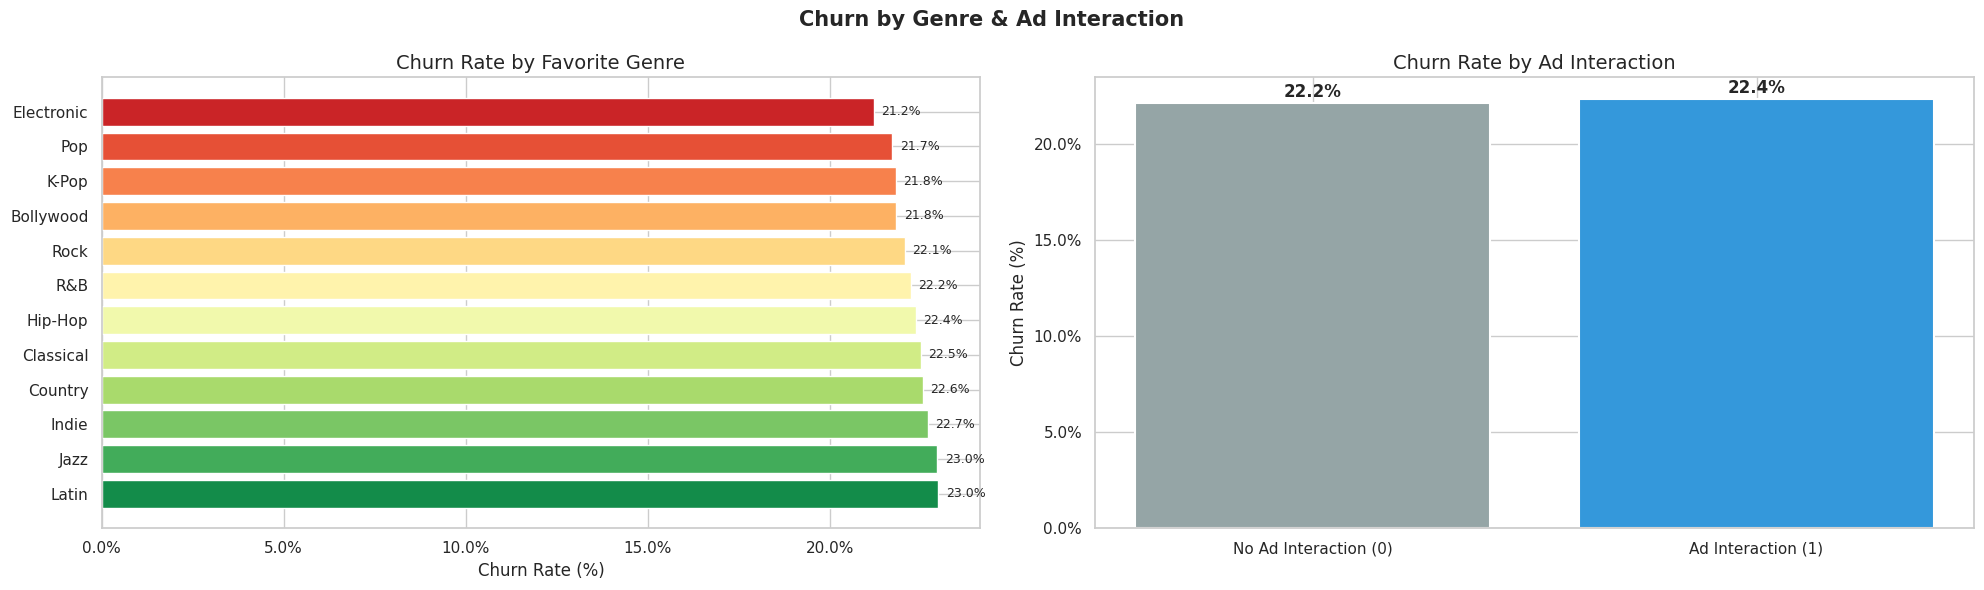

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Churn by favorite genre
genre_churn = df.groupby('favorite_genre')['inactive_3_months_flag'].mean().sort_values(ascending=False) * 100
axes[0].barh(genre_churn.index, genre_churn.values,
             color=sns.color_palette("RdYlGn_r", len(genre_churn)), edgecolor='white')
axes[0].set_title('Churn Rate by Favorite Genre')
axes[0].set_xlabel('Churn Rate (%)')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(genre_churn.values):
    axes[0].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)

# Churn by ad interaction
ad_churn = df.groupby('ad_interaction')['inactive_3_months_flag'].mean() * 100
axes[1].bar(['No Ad Interaction (0)', 'Ad Interaction (1)'], ad_churn.values,
            color=['#95a5a6', '#3498db'], edgecolor='white', linewidth=1.5)
axes[1].set_title('Churn Rate by Ad Interaction')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(ad_churn.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Churn by Genre & Ad Interaction', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/08_genre_ad_churn.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:

## 10. EDA Summary — Key Findings
# A consolidated summary of all insights uncovered in this notebook, translated into actionable churn signals.

In [ ]:
print("=" * 60)
print("          EDA SUMMARY — SPOTIFY CHURN ANALYSIS")
print("=" * 60)

print(f"\n📊 Dataset: {df.shape[0]:,} users | {df.shape[1]} features")
print(f"\n🔴 Churn Rate:            {df['inactive_3_months_flag'].mean()*100:.2f}%")
print(f"🟡 At-Risk Users (≥2mo):  {(df['months_inactive'] >= 2).mean()*100:.2f}%")
print(f"🟢 Active Users:           {(df['inactive_3_months_flag'] == 0).mean()*100:.2f}%")

print(f"\n📉 Avg Listening Hours/Week:  {df['avg_listening_hours_per_week'].mean():.2f}")
print(f"⏭️  Avg Skips/Day:             {df['avg_skips_per_day'].mean():.2f}")
print(f"🎵 Avg Playlists Created:      {df['playlists_created'].mean():.2f}")
print(f"⭐ Avg Recommendation Rating:  {df['music_suggestion_rating_1_to_5'].mean():.2f}")
print(f"💡 Avg Engagement Score:       {df['engagement_score'].mean():.2f}")

print(f"\n🔥 Highest Churn Engagement Level:")
print(df.groupby('engagement_level')['inactive_3_months_flag'].mean().reindex(['Low','Medium','High']).mul(100).round(2))

print(f"\n💳 Highest Churn Subscription Type:")
print(df.groupby('subscription_type')['inactive_3_months_flag'].mean().mul(100).round(2))

print("\n" + "=" * 60)
print("  Proceed to: 04_statistical_analysis.ipynb")
print("=" * 60)

          EDA SUMMARY — SPOTIFY CHURN ANALYSIS

📊 Dataset: 50,000 users | 21 features

🔴 Churn Rate:            22.25%
🟡 At-Risk Users (≥2mo):  36.65%
🟢 Active Users:           77.75%

📉 Avg Listening Hours/Week:  9.99
⏭️  Avg Skips/Day:             10.03
🎵 Avg Playlists Created:      8.00
⭐ Avg Recommendation Rating:  3.64
💡 Avg Engagement Score:       3.39

🔥 Highest Churn Engagement Level:
engagement_level
Low       22.20
Medium    22.19
High      22.35
Name: inactive_3_months_flag, dtype: float64

💳 Highest Churn Subscription Type:
subscription_type
free                  21.94
premium duo           22.93
premium family        22.51
premium individual    22.35
student               22.50
Name: inactive_3_months_flag, dtype: float64

  Proceed to: 04_statistical_analysis.ipynb
